In [1]:
# ================================================
# PROJET 2 — Analyse E-commerce Brésilien (Olist)
# Dataset : kaggle.com/datasets/olistbr/brazilian-ecommerce
# Auteur : Islem
# Date : Juillet 2026
# ================================================

In [2]:
# --- IMPORTS ---
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# --- CHARGEMENT DES DONNÉES ---
orders = pd.read_csv(r"C:\Users\ISLEM\Documents\olist_orders_dataset.csv")
payments = pd.read_csv(r"C:\Users\ISLEM\Documents\olist_order_payments_dataset.csv")
items = pd.read_csv(r"C:\Users\ISLEM\Documents\olist_order_items_dataset.csv")
products = pd.read_csv(r"C:\Users\ISLEM\Documents\olist_products_dataset.csv")

print(f"Commandes : {orders.shape[0]}")
print(f"Paiements : {payments.shape[0]}")
print(f"Articles : {items.shape[0]}")
print(f"Produits : {products.shape[0]}")

Commandes : 99441
Paiements : 103886
Articles : 112650
Produits : 32951


In [4]:
# --- FUSION DES DONNÉES ---
df = orders.merge(payments, on='order_id')
df2 = df.merge(items, on='order_id')
df3 = df2.merge(products, on='product_id')

print(f"Dataset final : {df3.shape[0]} lignes x {df3.shape[1]} colonnes")

Dataset final : 117601 lignes x 26 colonnes


In [5]:
# --- ANALYSE 1 : STATUTS DES COMMANDES ---
print(orders['order_status'].value_counts())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [6]:
# --- ANALYSE 2 : CHIFFRE D'AFFAIRES PAR STATUT ---
df.groupby('order_status')['payment_value'].sum().sort_values(ascending=False)

order_status
delivered      15422461.77
shipped          177213.96
canceled         143255.60
unavailable      126479.51
processing        69394.11
invoiced          69137.99
created             688.10
approved            241.08
Name: payment_value, dtype: float64

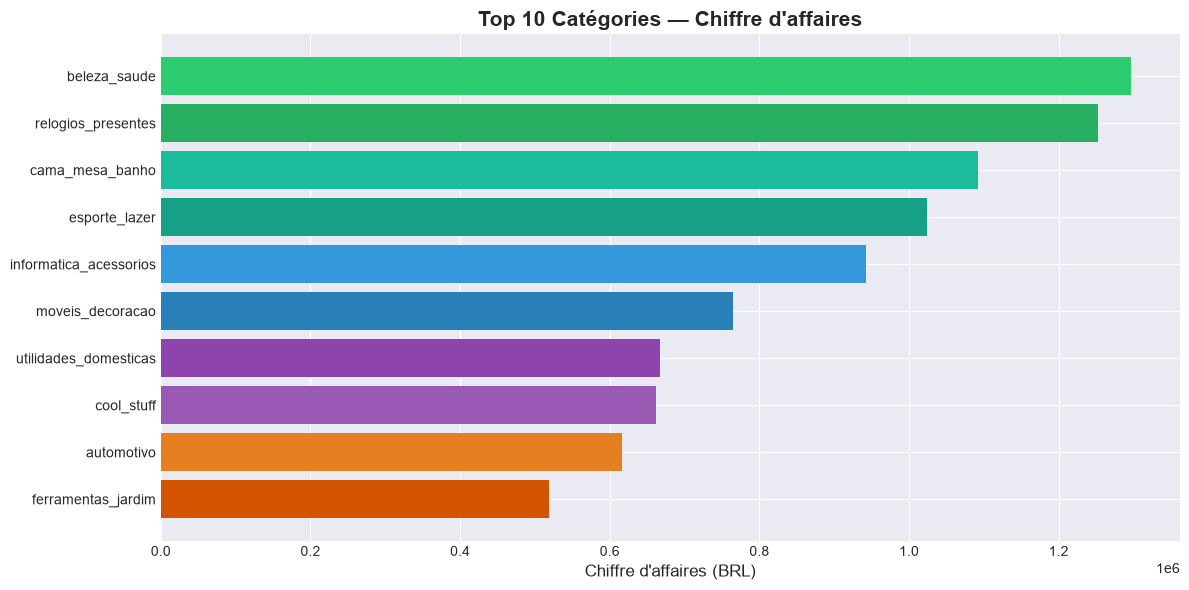

In [8]:
# --- ANALYSE 3 : TOP CATÉGORIES PRODUITS ---
plt.style.use('seaborn-v0_8-darkgrid')

top_categories = df3.groupby('product_category_name')['price'].sum().sort_values(ascending=False).head(10)

colors = ['#2ecc71', '#27ae60', '#1abc9c', '#16a085', '#3498db', 
          '#2980b9', '#8e44ad', '#9b59b6', '#e67e22', '#d35400']

plt.figure(figsize=(12, 6))
plt.barh(top_categories.index, top_categories.values, color=colors)
plt.xlabel("Chiffre d'affaires (BRL)", fontsize=12)
plt.title('Top 10 Catégories — Chiffre d\'affaires', fontsize=15, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

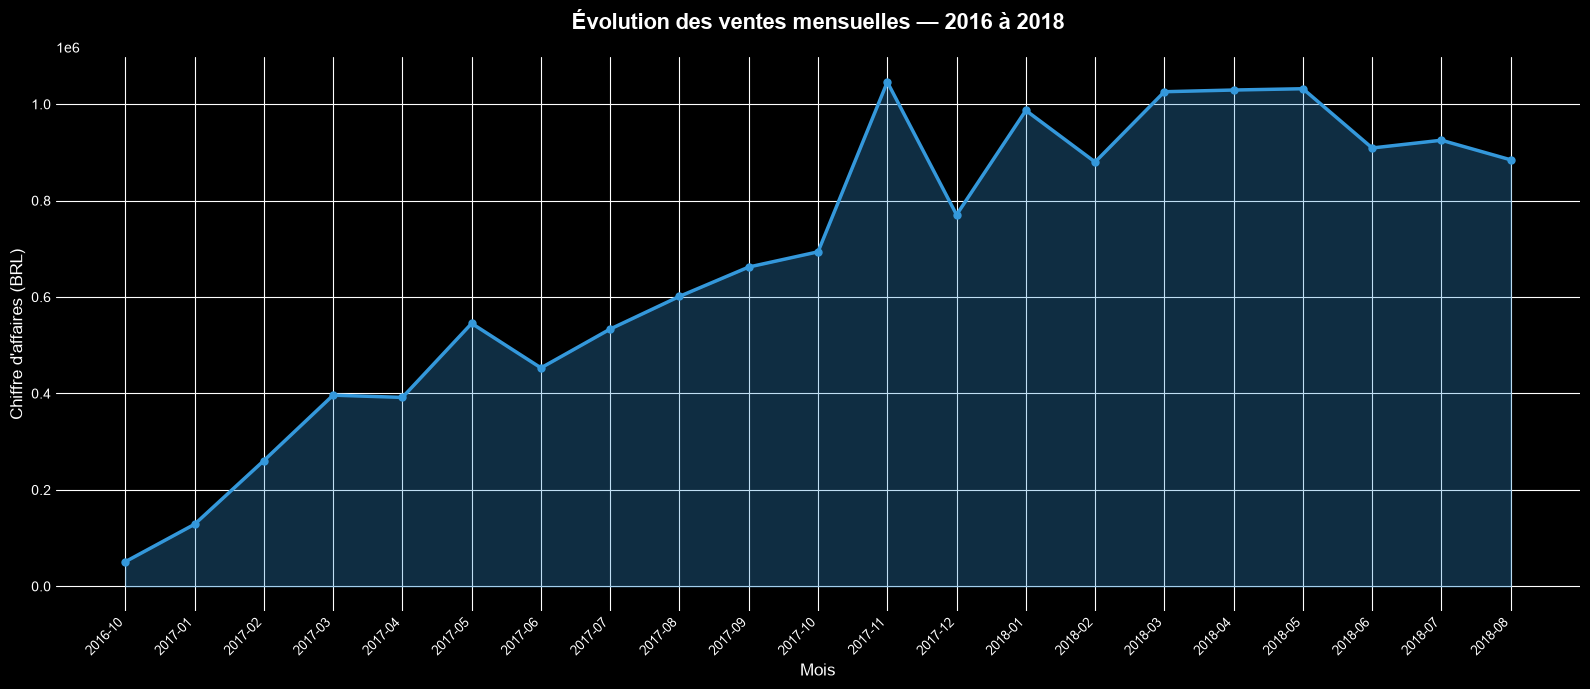

In [11]:
# --- ANALYSE 4 : ÉVOLUTION DES VENTES MENSUELLES ---
df3['order_purchase_timestamp'] = pd.to_datetime(df3['order_purchase_timestamp'])
df3['month'] = df3['order_purchase_timestamp'].dt.to_period('M')

ventes_mensuelles = df3.groupby('month')['price'].sum()

# Supprimer les mois incomplets
ventes_mensuelles = ventes_mensuelles[ventes_mensuelles > 1000]

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(16, 7))

ax.fill_between(range(len(ventes_mensuelles)), ventes_mensuelles.values, alpha=0.3, color='#3498db')
ax.plot(range(len(ventes_mensuelles)), ventes_mensuelles.values, color='#3498db', linewidth=2.5, marker='o', markersize=5)

ax.set_xticks(range(len(ventes_mensuelles)))
ax.set_xticklabels([str(m) for m in ventes_mensuelles.index], rotation=45, ha='right', fontsize=9)
ax.set_title('Évolution des ventes mensuelles — 2016 à 2018', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Mois', fontsize=12)
ax.set_ylabel("Chiffre d'affaires (BRL)", fontsize=12)

plt.tight_layout()
plt.show()

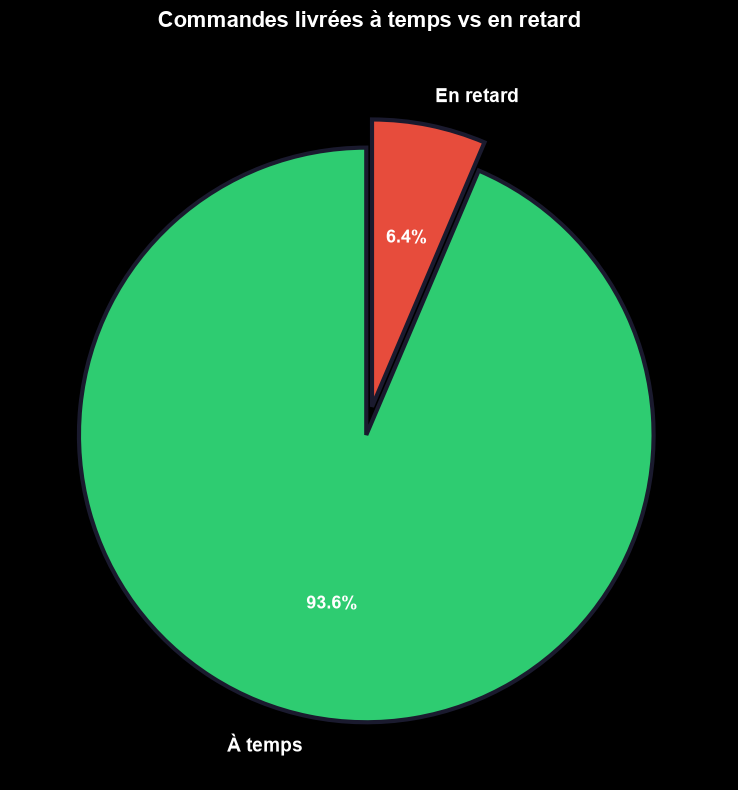

In [12]:
# --- ANALYSE 5 : DÉLAIS DE LIVRAISON ---
df3['order_delivered_customer_date'] = pd.to_datetime(df3['order_delivered_customer_date'])
df3['order_estimated_delivery_date'] = pd.to_datetime(df3['order_estimated_delivery_date'])

df3['delai_retard'] = (df3['order_delivered_customer_date'] - df3['order_estimated_delivery_date']).dt.days
df3['statut_livraison'] = df3['delai_retard'].apply(lambda x: 'En retard' if x > 0 else 'À temps')

statuts = df3['statut_livraison'].value_counts()

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    statuts.values,
    labels=statuts.index,
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    explode=(0.05, 0.05),
    wedgeprops={'linewidth': 3, 'edgecolor': '#1a1a2e'}
)

for text in texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title('Commandes livrées à temps vs en retard', 
             fontsize=16, fontweight='bold', pad=25, color='white')

plt.tight_layout()
plt.show()